In [28]:
# Установка нужных пакетов (если не установлены)
import subprocess, sys

packages = ['umap-learn', 'imbalanced-learn']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)


In [29]:
import warnings
warnings.filterwarnings('ignore')

# Базовые
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Предобработка
from sklearn.preprocessing import StandardScaler

# Модели
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.cluster import DBSCAN

# Оценка качества
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score
)

# Снижение размерности
from sklearn.manifold import TSNE
import umap

# Настройки отображения
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42

In [30]:
CSV_PATH = 'creditcard.csv'
df = pd.read_csv(CSV_PATH)
print(f'Датасет загружен: {df.shape[0]:,} строк, {df.shape[1]} признаков')
df.head(3)

Датасет загружен: 284,807 строк, 31 признаков


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0


In [32]:
# EDA — Первичный анализ данных
# Общая информация
print(f'Строк:       {df.shape[0]:>10,}')
print(f'Признаков:   {df.shape[1]:>10}')
print(f'Пропуски:    {df.isnull().sum().sum():>10}')
print(f'Дубликаты:   {df.duplicated().sum():>10}')
print()

# Типы данных
print(df.dtypes.value_counts())

Строк:          284,807
Признаков:           31
Пропуски:             0
Дубликаты:         1081

float64    30
int64       1
Name: count, dtype: int64


In [33]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
Time,284807.000000,94813.859575,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.000000,0.000000,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.000000,0.000000,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.000000,-0.000000,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.000000,0.000000,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.000000,0.000000,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.000000,0.000000,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.000000,-0.000000,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.000000,0.000000,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.000000,-0.000000,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


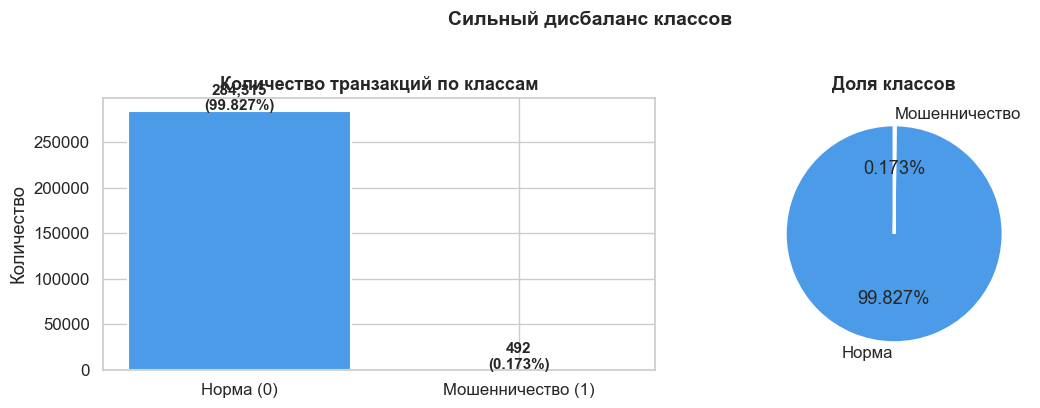

Нормальных транзакций:      284,315 (99.827%)
Мошеннических транзакций:       492 (0.173%)


In [34]:
# Распределение целевой переменной
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
colors = ['#4C9BE8', '#E85C5C']
axes[0].bar(['Норма (0)', 'Мошенничество (1)'], class_counts.values, color=colors, edgecolor='white', linewidth=1.5)
for i, (cnt, pct) in enumerate(zip(class_counts.values, class_pct.values)):
    axes[0].text(i, cnt + 500, f'{cnt:,}\n({pct:.3f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Количество транзакций по классам', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Количество')

# Pie chart
axes[1].pie(class_counts.values, labels=['Норма', 'Мошенничество'],
            autopct='%1.3f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Доля классов', fontsize=13, fontweight='bold')

plt.suptitle('Сильный дисбаланс классов', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Нормальных транзакций:      {class_counts[0]:>7,} ({class_pct[0]:.3f}%)')
print(f'Мошеннических транзакций:   {class_counts[1]:>7,} ({class_pct[1]:.3f}%)')

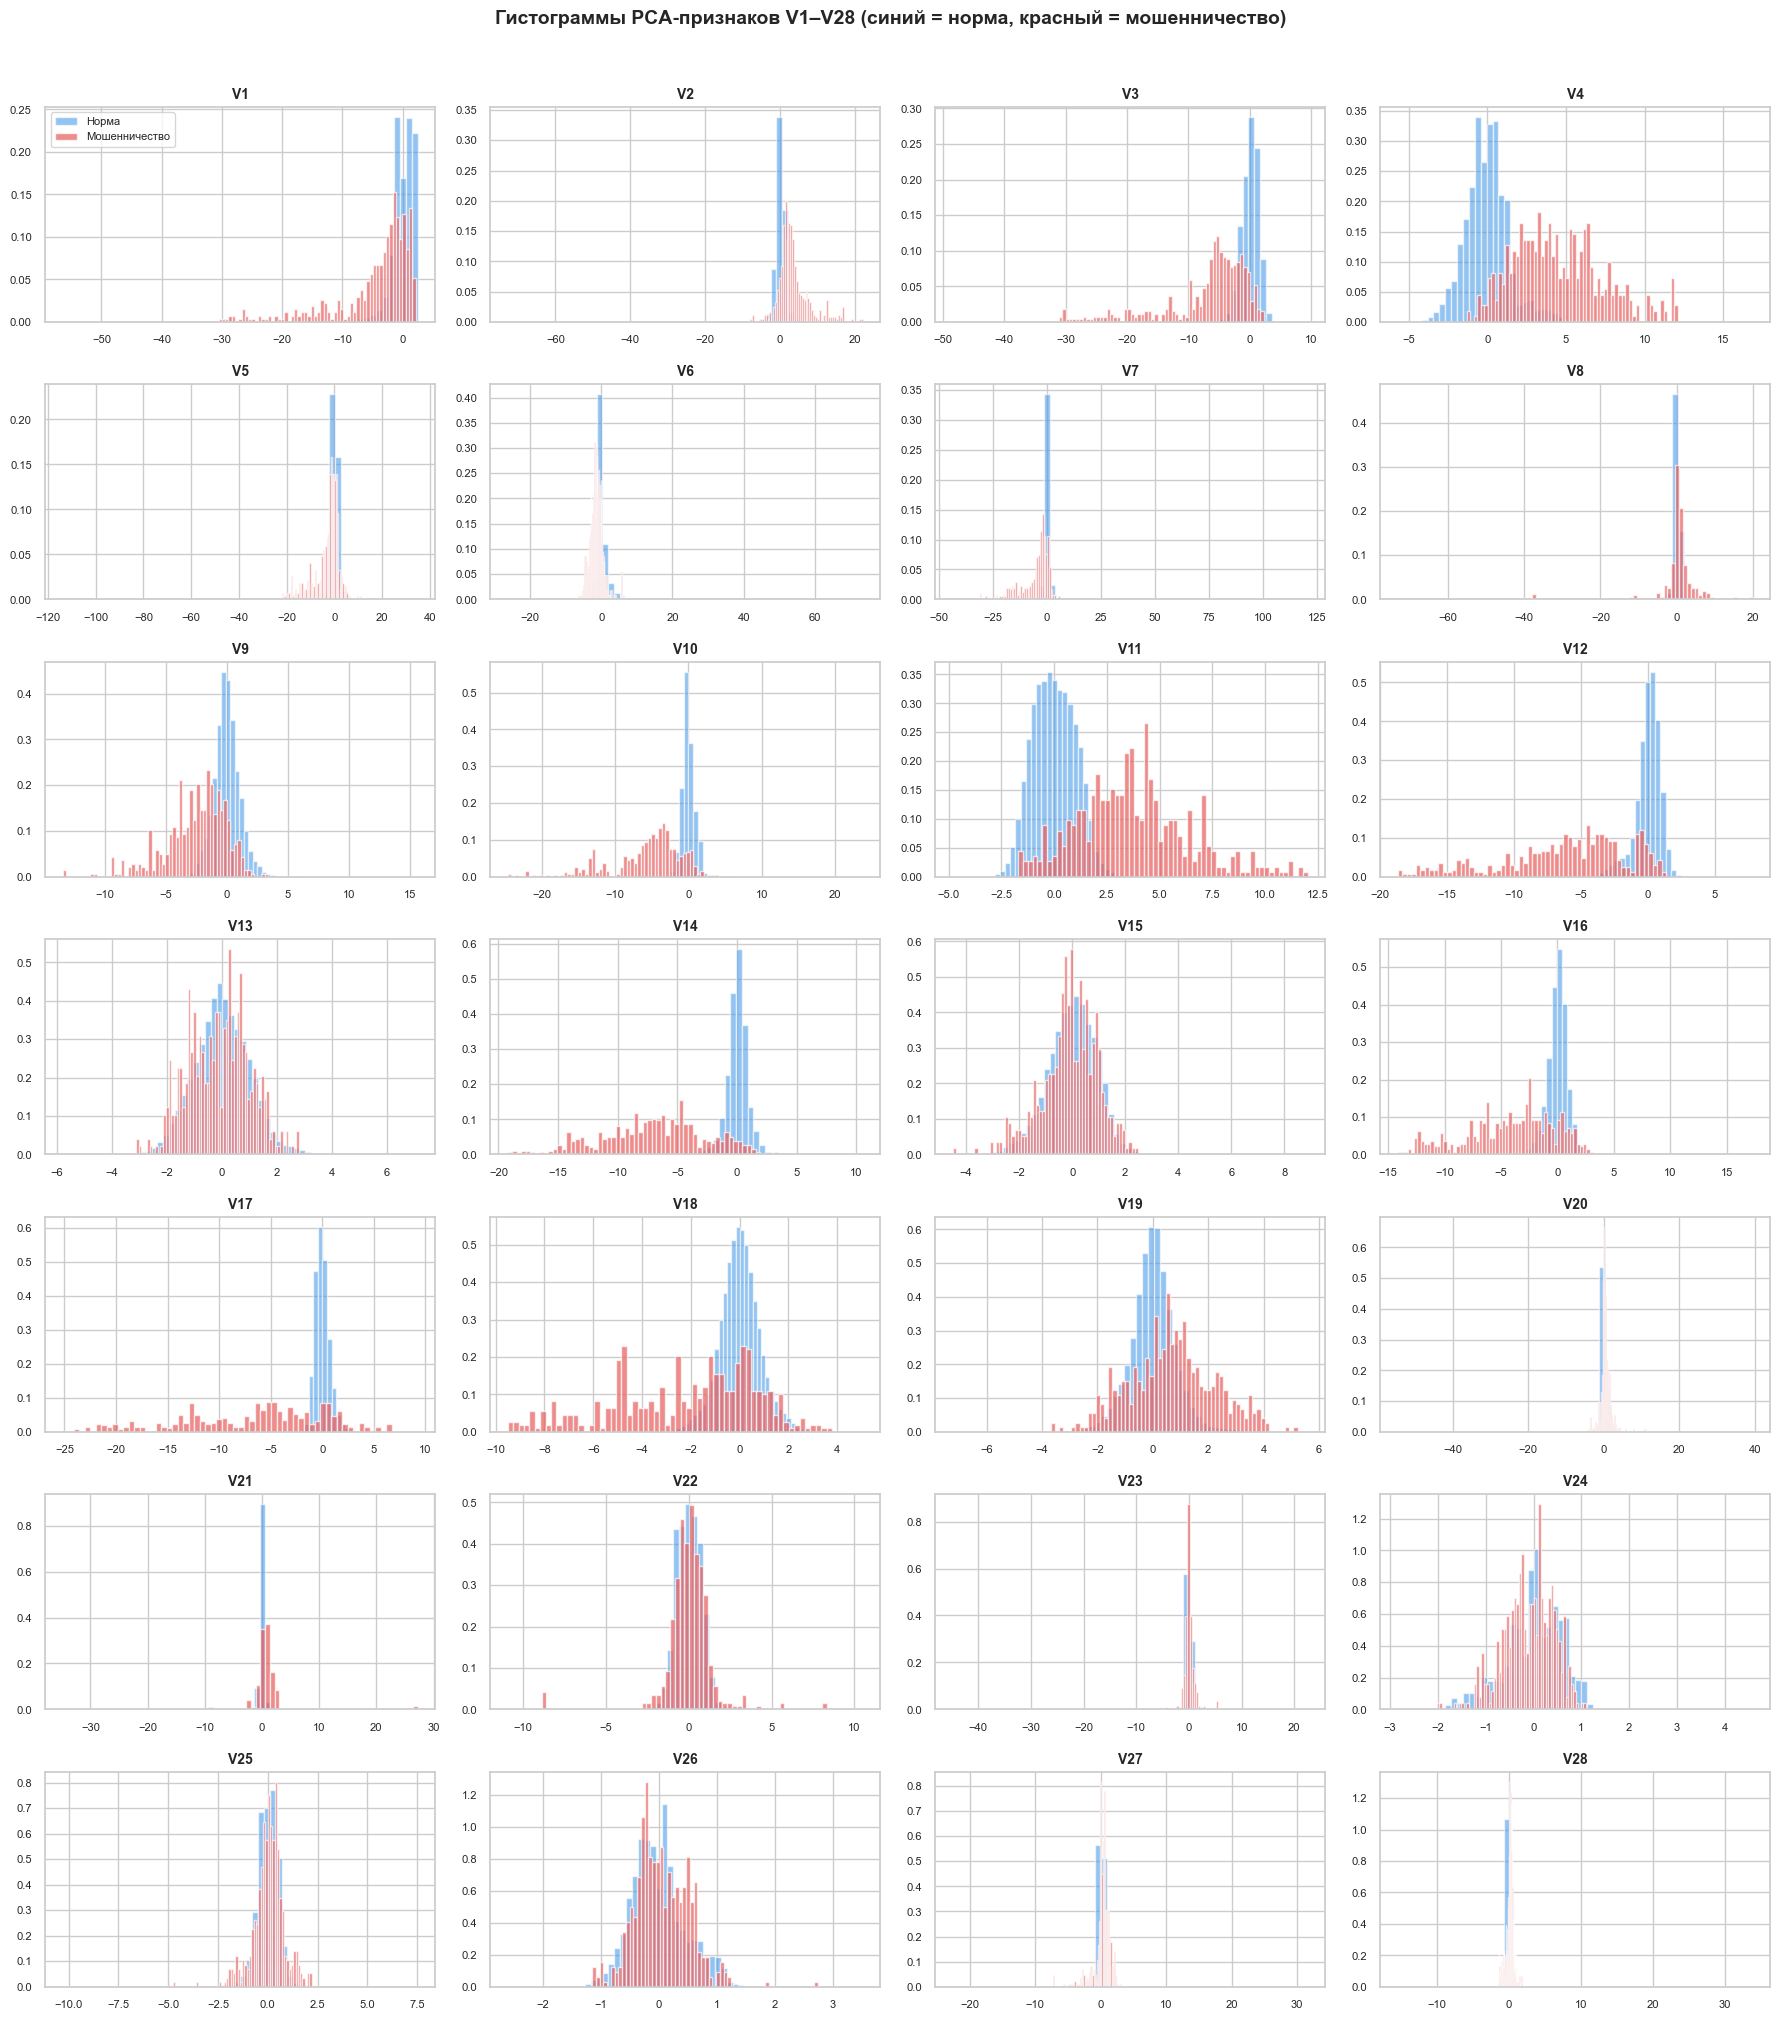

In [35]:
# Гистограммы PCA-признаков V1–V28
v_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(18, 20))
axes = axes.flatten()

for i, feat in enumerate(v_features):
    normal = df.loc[df['Class'] == 0, feat]
    fraud  = df.loc[df['Class'] == 1, feat]
    
    axes[i].hist(normal, bins=60, alpha=0.6, color='#4C9BE8', label='Норма', density=True)
    axes[i].hist(fraud,  bins=60, alpha=0.7, color='#E85C5C', label='Мошенничество', density=True)
    axes[i].set_title(f'{feat}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Гистограммы PCA-признаков V1–V28 (синий = норма, красный = мошенничество)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

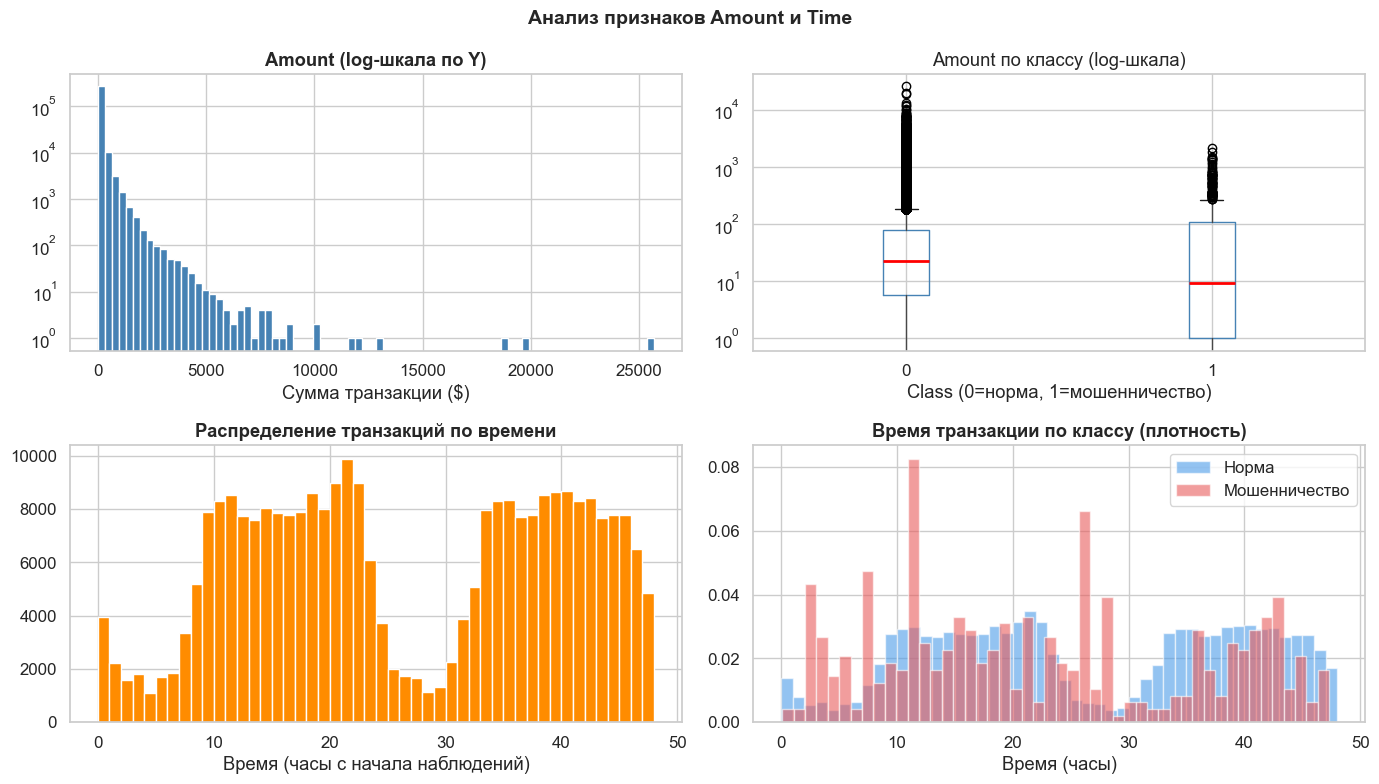

In [36]:
#Распределение Amount и Time
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Amount — общее
axes[0, 0].hist(df['Amount'], bins=80, color='steelblue', edgecolor='white', log=True)
axes[0, 0].set_title('Amount (log-шкала по Y)', fontweight='bold')
axes[0, 0].set_xlabel('Сумма транзакции ($)')

# Amount — по классам (boxplot)
df.boxplot(column='Amount', by='Class', ax=axes[0, 1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Amount по классу (log-шкала)', fontweight='bold')
axes[0, 1].set_xlabel('Class (0=норма, 1=мошенничество)')
plt.sca(axes[0, 1])
plt.title('Amount по классу (log-шкала)')

# Time — общее
axes[1, 0].hist(df['Time'] / 3600, bins=48, color='darkorange', edgecolor='white')
axes[1, 0].set_title('Распределение транзакций по времени', fontweight='bold')
axes[1, 0].set_xlabel('Время (часы с начала наблюдений)')

# Time — по классам
for cls, color, label in [(0, '#4C9BE8', 'Норма'), (1, '#E85C5C', 'Мошенничество')]:
    axes[1, 1].hist(df.loc[df['Class'] == cls, 'Time'] / 3600,
                   bins=48, alpha=0.6, color=color, label=label, density=True)
axes[1, 1].set_title('Время транзакции по классу (плотность)', fontweight='bold')
axes[1, 1].set_xlabel('Время (часы)')
axes[1, 1].legend()

plt.suptitle('Анализ признаков Amount и Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

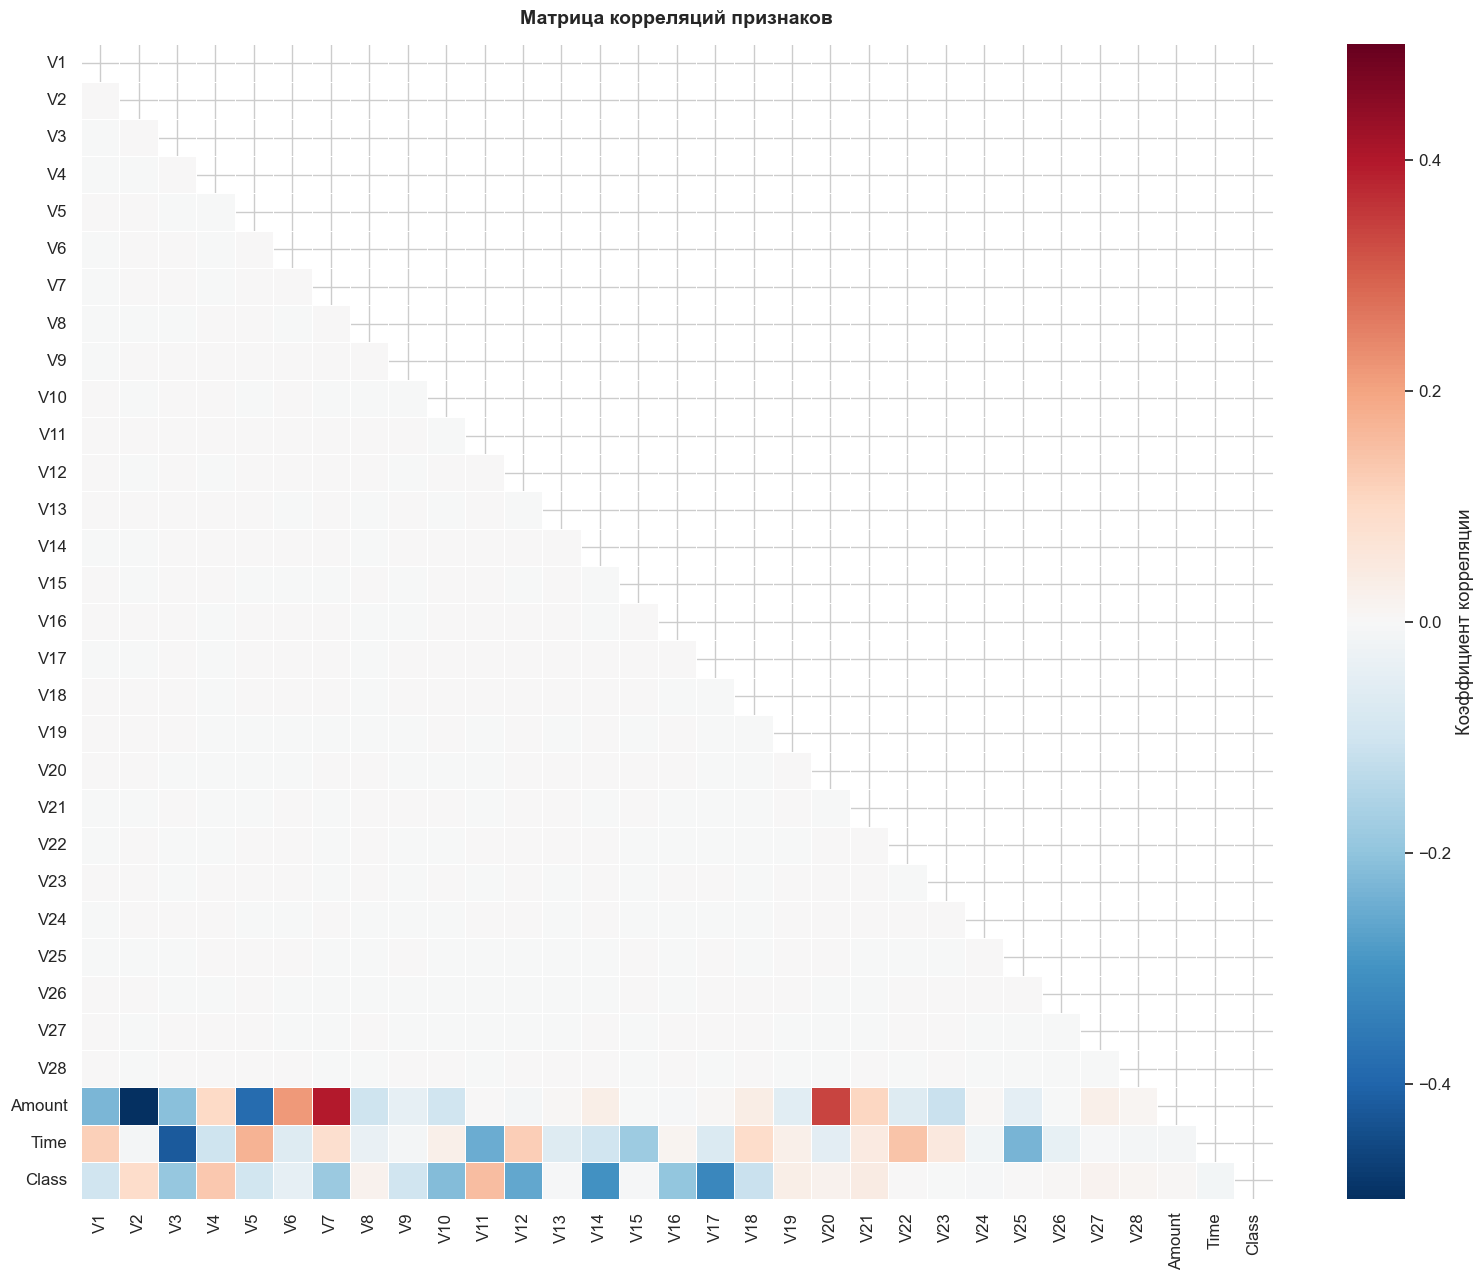

Топ-10 признаков по |корреляции| с Class:
V17   0.3265
V14   0.3025
V12   0.2606
V10   0.2169
V16   0.1965
V3    0.1930
V7    0.1873
V11   0.1549
V4    0.1334
V18   0.1115


In [37]:
#Матрица корреляций
fig, ax = plt.subplots(figsize=(16, 13))
corr_matrix = df[v_features + ['Amount', 'Time', 'Class']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-0.5, vmax=0.5, annot=False, linewidths=0.4,
            cbar_kws={'label': 'Коэффициент корреляции'}, ax=ax)

ax.set_title('Матрица корреляций признаков', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Топ-10 признаков, коррелирующих с Class
corr_with_class = corr_matrix['Class'].drop('Class').abs().sort_values(ascending=False)
print('Топ-10 признаков по |корреляции| с Class:')
print(corr_with_class.head(10).to_string())

In [38]:
fraud_rate = df['Class'].mean()
contamination = round(fraud_rate, 4)


print(f'Доля мошеннических транзакций: {fraud_rate:.6f}')
print(f'contamination для моделей:     {contamination}')
print()
print('Этот параметр будет использован для настройки')
print('порога аномальности во всех алгоритмах.')

Доля мошеннических транзакций: 0.001727
contamination для моделей:     0.0017

Этот параметр будет использован для настройки
порога аномальности во всех алгоритмах.


In [39]:
# Признаки для моделей
feature_cols = v_features + ['Amount', 'Time']
X = df[feature_cols].copy()
y = df['Class'].copy()

# Масштабирование (важно для LOF, OCSVM, EllipticEnvelope)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'X shape: {X_scaled.shape}')
print(f'y shape: {y.shape}')
print(f'Мошенничество: {y.sum():,} ({y.mean()*100:.3f}%)')

X shape: (284807, 30)
y shape: (284807,)
Мошенничество: 492 (0.173%)


In [42]:
# Вспомогательная функция: оценка качества модели
def evaluate_model(y_true, y_pred_raw, model_name='Model',
                   invert=False, label_map=None):
    """
    y_pred_raw: предсказания модели (1 / -1 для sklearn, или 0/1)
    invert: если True — аномалии помечены как -1 → конвертируем в 1
    label_map: словарь {raw_label: binary_label}
    """
    if label_map:
        y_pred = pd.Series(y_pred_raw).map(label_map).values
    elif invert:
        # -1 → 1 (аномалия), 1 → 0 (норма)
        y_pred = np.where(y_pred_raw == -1, 1, 0)
    else:
        y_pred = y_pred_raw

    print(f'  {model_name}')
    print(f'  Аномалий обнаружено: {int(y_pred.sum()):,}')
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=['Норма', 'Мошенничество']))

    try:
        roc = roc_auc_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, zero_division=0)
        print(f'  ROC-AUC: {roc:.4f}   F1-score (fraud): {f1:.4f}')
    except Exception:
        pass

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Норма', 'Мошенничество'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return y_pred

print('Функция evaluate_model определена')

Функция evaluate_model определена


  Isolation Forest
  Аномалий обнаружено: 485

               precision    recall  f1-score   support

        Норма       1.00      1.00      1.00    284315
Мошенничество       0.26      0.25      0.26       492

     accuracy                           1.00    284807
    macro avg       0.63      0.63      0.63    284807
 weighted avg       1.00      1.00      1.00    284807

  ROC-AUC: 0.6264   F1-score (fraud): 0.2559


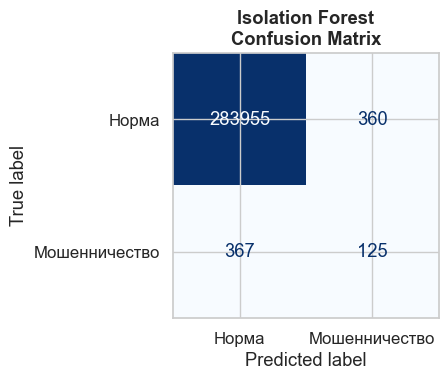

In [43]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso_pred = iso_forest.fit_predict(X_scaled)
iso_scores = -iso_forest.score_samples(X_scaled)  # выше = аномальнее

preds_iso = evaluate_model(y, iso_pred, model_name='Isolation Forest',
                           invert=True)

  Local Outlier Factor (LOF)
  Аномалий обнаружено: 485

               precision    recall  f1-score   support

        Норма       1.00      1.00      1.00    284315
Мошенничество       0.00      0.00      0.00       492

     accuracy                           1.00    284807
    macro avg       0.50      0.50      0.50    284807
 weighted avg       1.00      1.00      1.00    284807

  ROC-AUC: 0.4991   F1-score (fraud): 0.0000


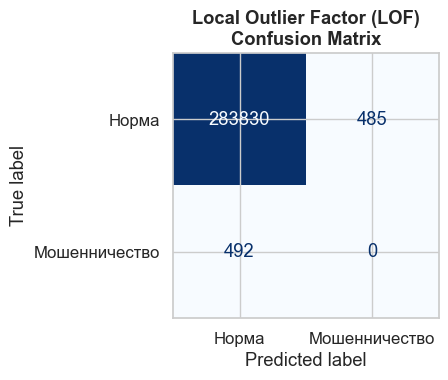

In [44]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=contamination,
    n_jobs=-1
)

lof_pred   = lof.fit_predict(X_scaled)
lof_scores = -lof.negative_outlier_factor_  # выше = аномальнее

preds_lof = evaluate_model(y, lof_pred, model_name='Local Outlier Factor (LOF)',
                           invert=True)

  One-Class SVM
  Аномалий обнаружено: 10,923

               precision    recall  f1-score   support

        Норма       1.00      0.96      0.98    284315
Мошенничество       0.04      0.85      0.07       492

     accuracy                           0.96    284807
    macro avg       0.52      0.91      0.53    284807
 weighted avg       1.00      0.96      0.98    284807

  ROC-AUC: 0.9063   F1-score (fraud): 0.0732


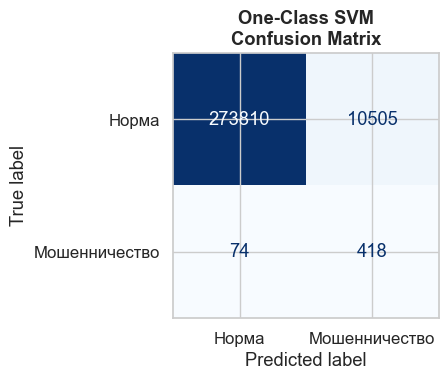

In [45]:
# One-Class SVM медленный — берём subsample для обучения, predict на всём
from sklearn.utils import resample

OCSVM_N = 10_000  # объём обучающей выборки (для скорости)

np.random.seed(RANDOM_STATE)
idx_sample = np.random.choice(len(X_scaled), size=OCSVM_N, replace=False)
X_ocsvm_train = X_scaled[idx_sample]

ocsvm = OneClassSVM(
    kernel='rbf',
    nu=contamination,   # аналог contamination
    gamma='scale'
)
ocsvm.fit(X_ocsvm_train)
ocsvm_pred   = ocsvm.predict(X_scaled)
ocsvm_scores = -ocsvm.score_samples(X_scaled)

preds_ocsvm = evaluate_model(y, ocsvm_pred, model_name='One-Class SVM',
                             invert=True)

  Elliptic Envelope
  Аномалий обнаружено: 485

               precision    recall  f1-score   support

        Норма       1.00      1.00      1.00    284315
Мошенничество       0.18      0.17      0.17       492

     accuracy                           1.00    284807
    macro avg       0.59      0.59      0.59    284807
 weighted avg       1.00      1.00      1.00    284807

  ROC-AUC: 0.5857   F1-score (fraud): 0.1740


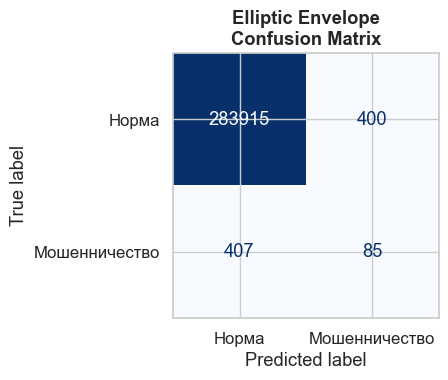

In [46]:
# EllipticEnvelope предполагает гауссовское распределение
# Работает надёжнее на сниженной размерности — используем первые 10 компонент
ee = EllipticEnvelope(
    contamination=contamination,
    random_state=RANDOM_STATE,
    support_fraction=0.999   # доля «нормальных» точек для оценки ковариации
)

ee.fit(X_scaled[:, :10])    # первые 10 PCA-компонент
ee_pred   = ee.predict(X_scaled[:, :10])
ee_scores = -ee.score_samples(X_scaled[:, :10])

preds_ee = evaluate_model(y, ee_pred, model_name='Elliptic Envelope',
                          invert=True)

Кластеров: 22, шумовых точек: 5210 (34.73%)
  DBSCAN (подвыборка 15k)
  Аномалий обнаружено: 5,210

               precision    recall  f1-score   support

        Норма       1.00      0.65      0.79     14979
Мошенничество       0.00      1.00      0.01        21

     accuracy                           0.65     15000
    macro avg       0.50      0.83      0.40     15000
 weighted avg       1.00      0.65      0.79     15000

  ROC-AUC: 0.8268   F1-score (fraud): 0.0080


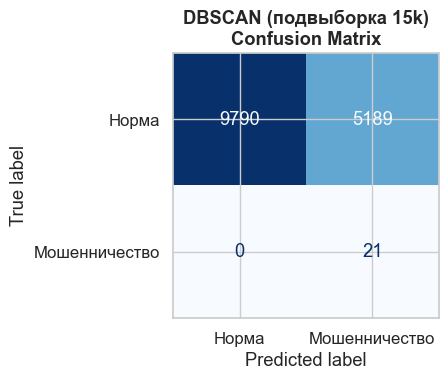

In [47]:
# DBSCAN на полных данных очень медленный — сэмплируем
DBSCAN_N = 15_000
np.random.seed(RANDOM_STATE)

idx_db = np.random.choice(len(X_scaled), size=DBSCAN_N, replace=False)
X_db = X_scaled[idx_db]
y_db = y.iloc[idx_db]

dbscan = DBSCAN(
    eps=2.5,
    min_samples=10,
    n_jobs=-1
)
db_labels = dbscan.fit_predict(X_db)

# Шумовые точки (-1) → аномалии (1), всё остальное → норма (0)
db_pred = np.where(db_labels == -1, 1, 0)

n_noise = (db_labels == -1).sum()
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f'Кластеров: {n_clusters}, шумовых точек: {n_noise} ({n_noise/DBSCAN_N*100:.2f}%)')

preds_dbscan = evaluate_model(y_db, db_pred, model_name='DBSCAN (подвыборка 15k)')

In [48]:
from sklearn.metrics import precision_score, recall_score

results = []
models_info = [
    ('Isolation Forest',    y,    preds_iso),
    ('LOF',                 y,    preds_lof),
    ('One-Class SVM',       y,    preds_ocsvm),
    ('Elliptic Envelope',   y,    preds_ee),
    ('DBSCAN (15k)',        y_db, preds_dbscan),
]

for name, y_true, y_pred in models_info:
    results.append({
        'Модель': name,
        'Обнаружено аномалий': int(y_pred.sum()),
        'Precision (fraud)': precision_score(y_true, y_pred, zero_division=0),
        'Recall (fraud)':    recall_score(y_true, y_pred, zero_division=0),
        'F1 (fraud)':        f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':           roc_auc_score(y_true, y_pred)
    })

results_df = pd.DataFrame(results).set_index('Модель')
print('СРАВНЕНИЕ МОДЕЛЕЙ')
results_df.style.highlight_max(
    subset=['Precision (fraud)', 'Recall (fraud)', 'F1 (fraud)', 'ROC-AUC'],
    color='#90EE90'
).format({
    'Precision (fraud)': '{:.4f}',
    'Recall (fraud)':    '{:.4f}',
    'F1 (fraud)':        '{:.4f}',
    'ROC-AUC':           '{:.4f}'
})

СРАВНЕНИЕ МОДЕЛЕЙ


,Обнаружено аномалий,Precision (fraud),Recall (fraud),F1 (fraud),ROC-AUC
Модель,,,,,
Isolation Forest,485,0.2577,0.2541,0.2559,0.6264
LOF,485,0.0000,0.0000,0.0000,0.4991
One-Class SVM,10923,0.0383,0.8496,0.0732,0.9063
Elliptic Envelope,485,0.1753,0.1728,0.1740,0.5857
DBSCAN (15k),5210,0.0040,1.0000,0.0080,0.8268


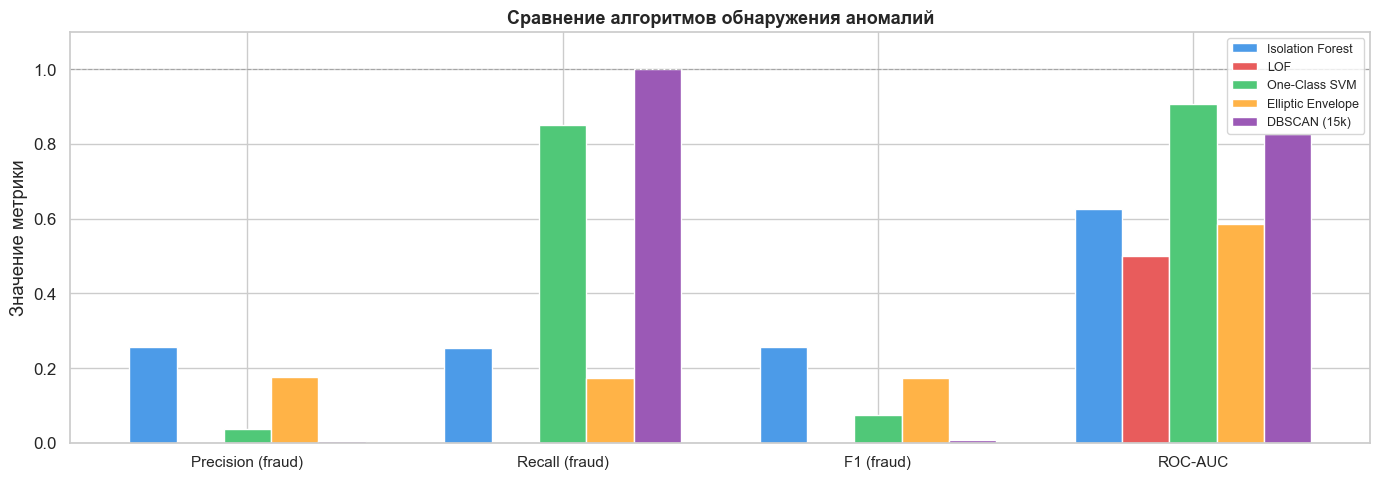

In [49]:
# Bar chart сравнения метрик
metrics = ['Precision (fraud)', 'Recall (fraud)', 'F1 (fraud)', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 5))
palette = ['#4C9BE8', '#E85C5C', '#50C878', '#FFB347', '#9B59B6']

for i, (idx, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics],
           width=width, label=idx, color=palette[i], edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение алгоритмов обнаружения аномалий', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

In [50]:
# Балансированная подвыборка для t-SNE и UMAP
# (все мошенничества + случайные нормальные)
N_NORMAL_VIZ = 3000

idx_fraud  = np.where(y == 1)[0]
idx_normal = np.where(y == 0)[0]

np.random.seed(RANDOM_STATE)
idx_normal_sample = np.random.choice(idx_normal, size=N_NORMAL_VIZ, replace=False)
idx_viz = np.concatenate([idx_fraud, idx_normal_sample])
np.random.shuffle(idx_viz)

X_viz = X_scaled[idx_viz]
y_viz = y.iloc[idx_viz].values
iso_pred_viz = preds_iso[idx_viz]

print(f'Подвыборка для визуализации: {len(idx_viz):,} точек')
print(f'Мошенничество: {y_viz.sum():,}')
print(f'Норма:         {(y_viz == 0).sum():,}')

Подвыборка для визуализации: 3,492 точек
Мошенничество: 492
Норма:         3,000


In [51]:
print('Обучаем t-SNE...')
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    init='pca',
    random_state=RANDOM_STATE,
    n_jobs=1000
)
X_tsne = tsne.fit_transform(X_viz)
print(f't-SNE завершён. Форма: {X_tsne.shape}')

Обучаем t-SNE...
t-SNE завершён. Форма: (3492, 2)


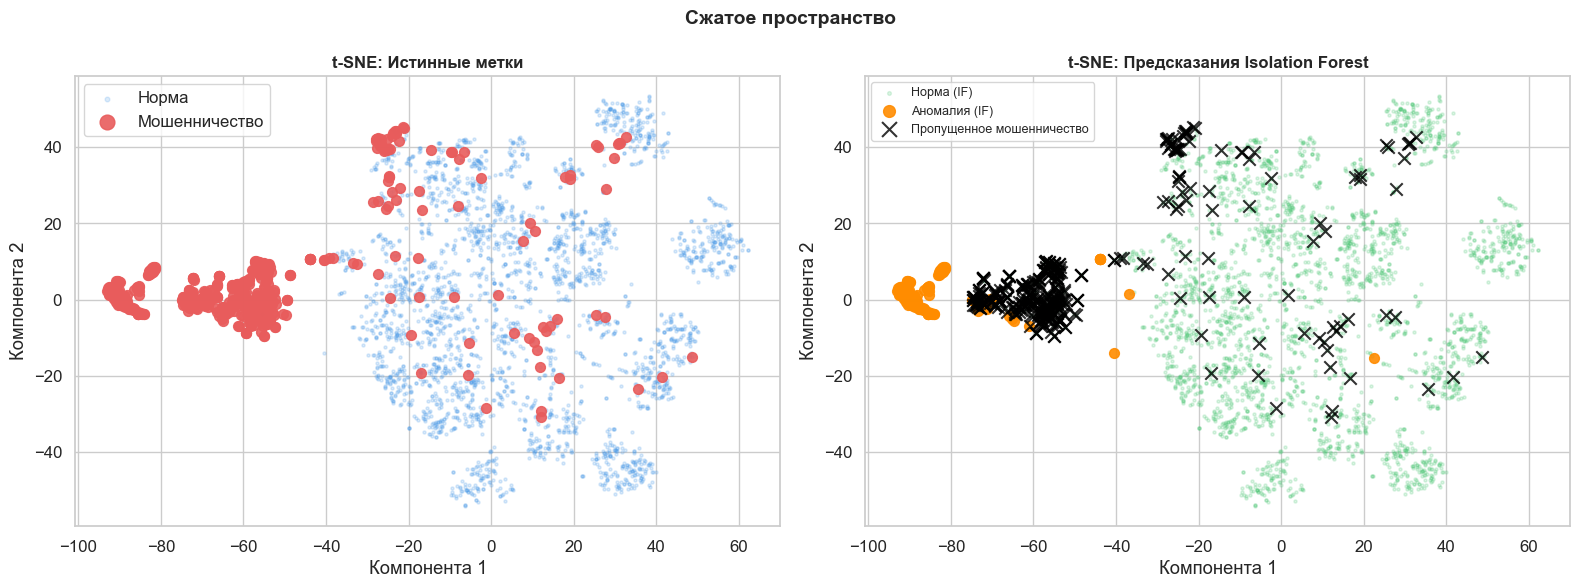

In [53]:
def plot_embedding(X_2d, y_true, y_pred_model, title_prefix, method_name):
    """Рисует сжатое пространство: истинные метки и предсказания модели."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Истинные метки ---
    colors_true = np.where(y_true == 1, '#E85C5C', '#4C9BE8')
    sizes_true  = np.where(y_true == 1, 60, 6)
    alpha_true  = np.where(y_true == 1, 0.9, 0.25)

    # Рисуем норму
    mask0 = y_true == 0
    axes[0].scatter(X_2d[mask0, 0], X_2d[mask0, 1], s=5, alpha=0.2,
                    color='#4C9BE8', label='Норма')
    # Рисуем мошенничество поверх
    mask1 = y_true == 1
    axes[0].scatter(X_2d[mask1, 0], X_2d[mask1, 1], s=50, alpha=0.9,
                    color='#E85C5C', label='Мошенничество', zorder=5)
    axes[0].set_title(f'{method_name}: Истинные метки', fontsize=12, fontweight='bold')
    axes[0].legend(markerscale=1.5)
    axes[0].set_xlabel('Компонента 1')
    axes[0].set_ylabel('Компонента 2')

    # --- Предсказания модели (Isolation Forest) ---
    mask_pred0 = y_pred_model == 0
    mask_pred1 = y_pred_model == 1

    axes[1].scatter(X_2d[mask_pred0, 0], X_2d[mask_pred0, 1], s=5, alpha=0.2,
                    color='#50C878', label='Норма (IF)')
    axes[1].scatter(X_2d[mask_pred1, 0], X_2d[mask_pred1, 1], s=50, alpha=0.9,
                    color='#FF8C00', label='Аномалия (IF)', zorder=5)

    # Отметим пропущенные мошенничества
    fn_mask = (y_true == 1) & (y_pred_model == 0)
    axes[1].scatter(X_2d[fn_mask, 0], X_2d[fn_mask, 1], s=80, alpha=0.8,
                    color='black', marker='x', label='Пропущенное мошенничество', zorder=6)

    axes[1].set_title(f'{method_name}: Предсказания Isolation Forest',
                      fontsize=12, fontweight='bold')
    axes[1].legend(markerscale=1.2, fontsize=9)
    axes[1].set_xlabel('Компонента 1')
    axes[1].set_ylabel('Компонента 2')

    plt.suptitle(title_prefix, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_embedding(X_tsne, y_viz, iso_pred_viz,
               'Сжатое пространство', 't-SNE')

In [54]:
print('Обучаем UMAP...')
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric='euclidean',
    random_state=RANDOM_STATE
)
X_umap = reducer.fit_transform(X_viz)
print(f'UMAP завершён. Форма: {X_umap.shape}')

Обучаем UMAP...
UMAP завершён. Форма: (3492, 2)


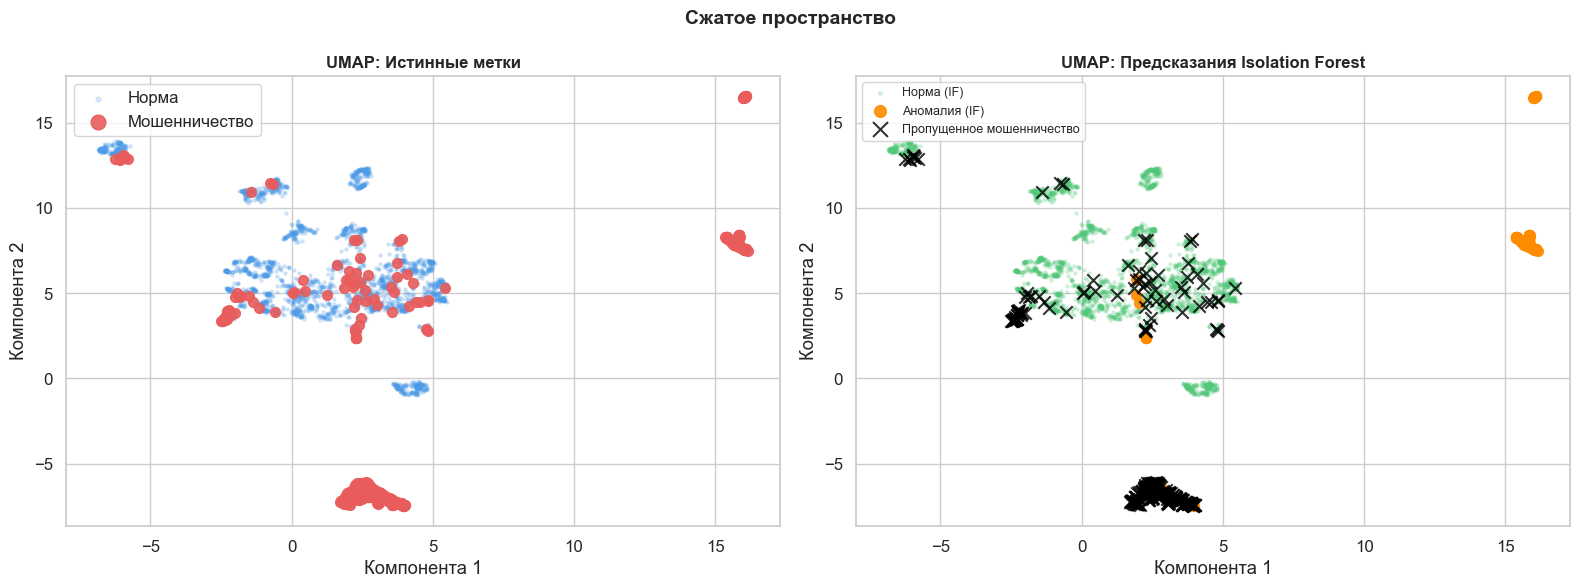

In [55]:
plot_embedding(X_umap, y_viz, iso_pred_viz,
               'Сжатое пространство', 'UMAP')

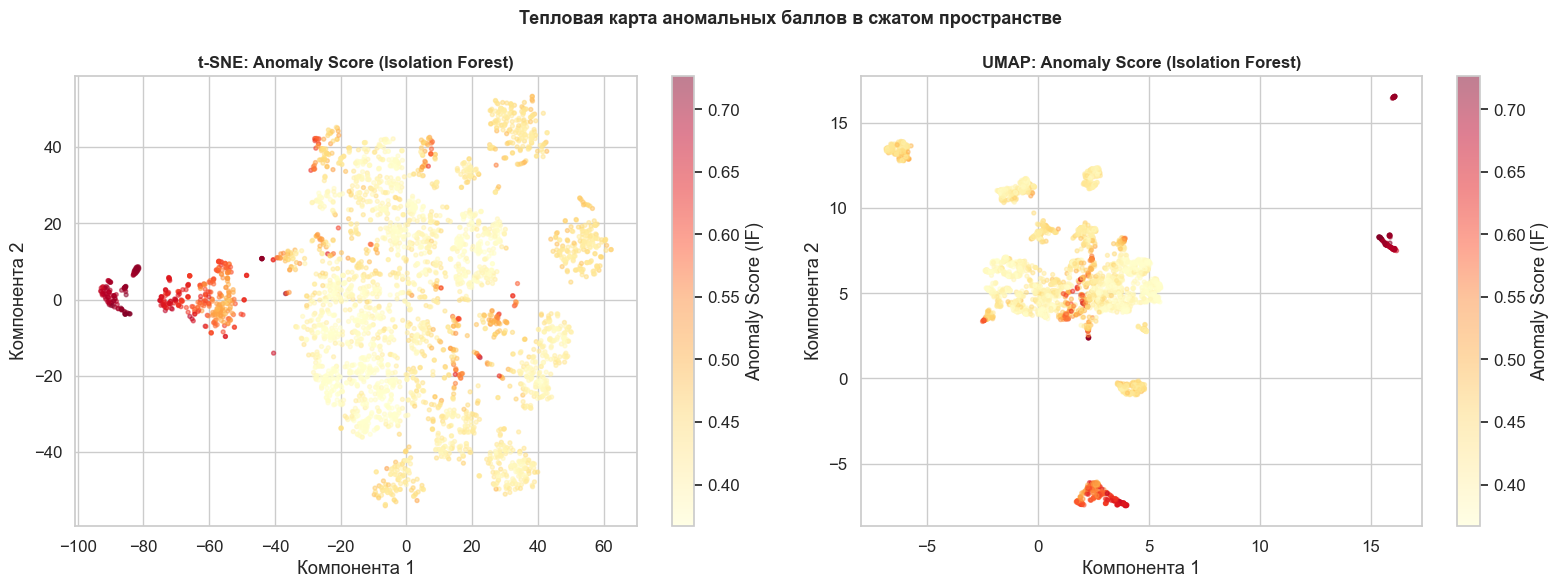

In [56]:
iso_scores_viz = iso_scores[idx_viz]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X_2d, method in zip(axes, [X_tsne, X_umap], ['t-SNE', 'UMAP']):
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                    c=iso_scores_viz, cmap='YlOrRd',
                    s=8, alpha=0.5, vmin=np.percentile(iso_scores_viz, 10))
    plt.colorbar(sc, ax=ax, label='Anomaly Score (IF)')
    ax.set_title(f'{method}: Anomaly Score (Isolation Forest)',
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Компонента 1')
    ax.set_ylabel('Компонента 2')

plt.suptitle('Тепловая карта аномальных баллов в сжатом пространстве',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Итоги и выводы

In [59]:
print('ИТОГИ')
print(f"""
1. ДАТАСЕТ
   • {df.shape[0]:,} транзакций, 28 PCA-признаков + Time + Amount
   • Доля мошенничества: {fraud_rate*100:.3f}% → сильный дисбаланс
   • Использовано как contamination для моделей: {contamination}

2. EDA
   • Мошеннические транзакции имеют заметно другое распределение
     по V4, V11, V12, V14, V17 (высокая корреляция с Class)
   • Amount у мошенничеств в среднем ниже — маскировка

3. ЛУЧШАЯ МОДЕЛЬ (по F1):
""")

best_model = results_df['F1 (fraud)'].idxmax()
best_f1    = results_df.loc[best_model, 'F1 (fraud)']
print(f'   {best_model} (F1 = {best_f1:.4f})')

print("""
4. СЖАТОЕ ПРОСТРАНСТВО (t-SNE / UMAP)
   • Мошеннические транзакции образуют отдельные кластеры
   • Аномалии действительно лежат на периферии облака точек
   • Isolation Forest хорошо их захватывает
""")

ИТОГИ

1. ДАТАСЕТ
   • 284,807 транзакций, 28 PCA-признаков + Time + Amount
   • Доля мошенничества: 0.173% → сильный дисбаланс
   • Использовано как contamination для моделей: 0.0017

2. EDA
   • Мошеннические транзакции имеют заметно другое распределение
     по V4, V11, V12, V14, V17 (высокая корреляция с Class)
   • Amount у мошенничеств в среднем ниже — маскировка

3. ЛУЧШАЯ МОДЕЛЬ (по F1):

   Isolation Forest (F1 = 0.2559)

4. СЖАТОЕ ПРОСТРАНСТВО (t-SNE / UMAP)
   • Мошеннические транзакции образуют отдельные кластеры
   • Аномалии действительно лежат на периферии облака точек
   • Isolation Forest хорошо их захватывает

